In [16]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Preprocessing
from sklearn.preprocessing import MinMaxScaler

# Wavelet
import pywt


In [17]:
# Load dataset
df = pd.read_csv('/content/PRSA_data_2010.1.1-2014.12.31 2.csv')

# Preview data
df.head()


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
0,1,2010,1,1,0,NaN,-21,-11.0,1021.0,NW,1.79,0,0
1,2,2010,1,1,1,NaN,-21,-12.0,1020.0,NW,4.92,0,0
2,3,2010,1,1,2,NaN,-21,-11.0,1019.0,NW,6.71,0,0
3,4,2010,1,1,3,NaN,-21,-14.0,1019.0,NW,9.84,0,0
4,5,2010,1,1,4,NaN,-20,-12.0,1018.0,NW,12.97,0,0


In [18]:
df['pm2.5'].isna().sum()


np.int64(2067)

In [19]:
df = df.dropna()
print("After cleaning:", df.shape)


After cleaning: (41757, 13)


In [20]:
# Create datetime column
df['datetime'] = pd.to_datetime(
    df[['year', 'month', 'day', 'hour']]
)

# Sort by time and set as index
df = df.sort_values('datetime')
df = df.set_index('datetime')

df.head()


,No,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
datetime,,,,,,,,,,,,,
2010-01-02 00:00:00,25,2010,1,2,0,129.0,-16,-4.0,1020.0,SE,1.79,0,0
2010-01-02 01:00:00,26,2010,1,2,1,148.0,-15,-4.0,1020.0,SE,2.68,0,0
2010-01-02 02:00:00,27,2010,1,2,2,159.0,-11,-5.0,1021.0,SE,3.57,0,0
2010-01-02 03:00:00,28,2010,1,2,3,181.0,-7,-5.0,1022.0,SE,5.36,1,0
2010-01-02 04:00:00,29,2010,1,2,4,138.0,-7,-5.0,1022.0,SE,6.25,2,0


In [21]:
features = ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']
df_model = df[features]

df_model.head()


,pm2.5,DEWP,TEMP,PRES,Iws
datetime,,,,,
2010-01-02 00:00:00,129.0,-16,-4.0,1020.0,1.79
2010-01-02 01:00:00,148.0,-15,-4.0,1020.0,2.68
2010-01-02 02:00:00,159.0,-11,-5.0,1021.0,3.57
2010-01-02 03:00:00,181.0,-7,-5.0,1022.0,5.36
2010-01-02 04:00:00,138.0,-7,-5.0,1022.0,6.25


In [22]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
scaled_data = scaler.fit_transform(df_model)

scaled_df = pd.DataFrame(
    scaled_data,
    columns=features,
    index=df_model.index
)

scaled_df.head()


,pm2.5,DEWP,TEMP,PRES,Iws
datetime,,,,,
2010-01-02 00:00:00,0.129779,0.352941,0.245902,0.527273,0.002372
2010-01-02 01:00:00,0.148893,0.367647,0.245902,0.527273,0.003947
2010-01-02 02:00:00,0.159960,0.426471,0.229508,0.545455,0.005522
2010-01-02 03:00:00,0.182093,0.485294,0.229508,0.563636,0.008690
2010-01-02 04:00:00,0.138833,0.485294,0.229508,0.563636,0.010265


In [23]:
import pywt

pm25 = scaled_df['pm2.5'].values

coeffs = pywt.wavedec(pm25, 'db4', level=3)
A3, D3, D2, D1 = coeffs

min_len = min(len(A3), len(D3))
A3 = A3[:min_len]
D3 = D3[:min_len]

wavelet_df = pd.DataFrame({
    'PM25_trend': A3,
    'PM25_noise': D3
}, index=scaled_df.index[:min_len])

wavelet_df.head()


,PM25_trend,PM25_noise
datetime,,
2010-01-02 00:00:00,0.417876,0.004733
2010-01-02 01:00:00,0.423929,0.017766
2010-01-02 02:00:00,0.425176,0.032565
2010-01-02 03:00:00,0.419990,0.010435
2010-01-02 04:00:00,0.438410,-0.005480


In [24]:
final_df = pd.concat(
    [wavelet_df, scaled_df.iloc[:min_len, 1:]],
    axis=1
)

final_df.head()


,PM25_trend,PM25_noise,DEWP,TEMP,PRES,Iws
datetime,,,,,,
2010-01-02 00:00:00,0.417876,0.004733,0.352941,0.245902,0.527273,0.002372
2010-01-02 01:00:00,0.423929,0.017766,0.367647,0.245902,0.527273,0.003947
2010-01-02 02:00:00,0.425176,0.032565,0.426471,0.229508,0.545455,0.005522
2010-01-02 03:00:00,0.419990,0.010435,0.485294,0.229508,0.563636,0.008690
2010-01-02 04:00:00,0.438410,-0.005480,0.485294,0.229508,0.563636,0.010265


In [25]:
import numpy as np

def create_sequences(data, window_size=24):
    X, y = [], []
    for i in range(len(data) - window_size):
        X.append(data.iloc[i:i+window_size].values)
        y.append(data.iloc[i+window_size]['PM25_trend'])
    return np.array(X), np.array(y)

X, y = create_sequences(final_df, window_size=24)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (5201, 24, 6)
y shape: (5201,)


In [26]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print("Train samples:", X_train.shape)
print("Test samples:", X_test.shape)


Train samples: (4160, 24, 6)
Test samples: (1041, 24, 6)


In [27]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Bidirectional, Dropout
from tensorflow.keras.callbacks import EarlyStopping

model_bilstm = Sequential([
    Bidirectional(LSTM(64, return_sequences=True),
                  input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.2),

    Bidirectional(LSTM(32)),
    Dropout(0.2),

    Dense(1)
])

model_bilstm.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_bilstm.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional) │ (None, 24, 128)        │        36,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 24, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 64)             │        41,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 77,633 (303.25 KB)

 Trainable params: 77,633 (303.25 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

history_bilstm = model_bilstm.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 0.0818 - mae: 0.2115 - val_loss: 0.0460 - val_mae: 0.1654
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 8s 34ms/step - loss: 0.0409 - mae: 0.1482 - val_loss: 0.0510 - val_mae: 0.1703
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 42ms/step - loss: 0.0361 - mae: 0.1375 - val_loss: 0.0345 - val_mae: 0.1361
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0368 - mae: 0.1403 - val_loss: 0.0331 - val_mae: 0.1314
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0317 - mae: 0.1293 - val_loss: 0.0316 - val_mae: 0.1271
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.0352 - mae: 0.1320 - val_loss: 0.0310 - val_mae: 0.1261
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms/step - loss: 0.0331 - mae: 0.1274 - val_loss: 0.0307 - val_mae: 0.1272
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.0310 - mae: 0.1250 - val_loss: 0.0304 - val_mae: 0.1250
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 35ms

In [29]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

y_pred_bilstm = model_bilstm.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred_bilstm))
mae = mean_absolute_error(y_test, y_pred_bilstm)
r2 = r2_score(y_test, y_pred_bilstm)

print("BiLSTM RMSE:", rmse)
print("BiLSTM MAE :", mae)
print("BiLSTM R²  :", r2)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
BiLSTM RMSE: 0.1684242607161991
BiLSTM MAE : 0.11680450817598542
BiLSTM R²  : 0.5845724217274612


In [30]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv1D, Bidirectional, LSTM,
    Dense, Dropout, Attention, GlobalAveragePooling1D
)

input_layer = Input(shape=(X_train.shape[1], X_train.shape[2]))

# Conv1D for local pattern extraction
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(input_layer)

# BiLSTM
x = Bidirectional(LSTM(64, return_sequences=True))(x)
x = Dropout(0.2)(x)

# Attention
attn = Attention()([x, x])
x = GlobalAveragePooling1D()(attn)

# Output
output = Dense(1)(x)

wvnet_model = Model(inputs=input_layer, outputs=output)

wvnet_model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

wvnet_model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 24, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 24, 64)    │      1,216 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_3     │ (None, 24, 128)   │     66,048 │ conv1d_1[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 24, 128)   │          0 │ bidirectional_3[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 24, 128)   │          0 │ dropout_3[0][0],  │
│ (Attention)         │                   │            │ dropout_3[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 128)       │          0 │ attention[0][0]   │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1)         │        129 │ global_average_p… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 67,393 (263.25 KB)

 Trainable params: 67,393 (263.25 KB)

 Non-trainable params: 0 (0.00 B)

In [31]:
history_wvnet = wvnet_model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 31ms/step - loss: 0.0688 - mae: 0.1981 - val_loss: 0.0597 - val_mae: 0.1845
Epoch 2/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 36ms/step - loss: 0.0465 - mae: 0.1618 - val_loss: 0.0359 - val_mae: 0.1311
Epoch 3/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - loss: 0.0300 - mae: 0.1260 - val_loss: 0.0319 - val_mae: 0.1371
Epoch 4/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/step - loss: 0.0319 - mae: 0.1293 - val_loss: 0.0305 - val_mae: 0.1252
Epoch 5/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - loss: 0.0297 - mae: 0.1246 - val_loss: 0.0300 - val_mae: 0.1304
Epoch 6/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - loss: 0.0278 - mae: 0.1207 - val_loss: 0.0329 - val_mae: 0.1474
Epoch 7/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - loss: 0.0284 - mae: 0.1207 - val_loss: 0.0305 - val_mae: 0.1359
Epoch 8/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - loss: 0.0267 - mae: 0.1183 - val_loss: 0.0283 - val_mae: 0.1205
Epoch 9/20
117/117 ━━━━━━━━━━━━━━━━━━━━ 3s 27ms/

In [32]:
y_pred_wvnet = wvnet_model.predict(X_test)

rmse_wv = np.sqrt(mean_squared_error(y_test, y_pred_wvnet))
mae_wv = mean_absolute_error(y_test, y_pred_wvnet)
r2_wv = r2_score(y_test, y_pred_wvnet)

print("WV-Net RMSE:", rmse_wv)
print("WV-Net MAE :", mae_wv)
print("WV-Net R²  :", r2_wv)


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step
WV-Net RMSE: 0.16192491087953415
WV-Net MAE : 0.1119542022903639
WV-Net R²  : 0.6160157971202203


# ======================================================
# EXPERIMENT 2: Improved WV-Net (Stronger Configuration)
# Goal: Beat BiLSTM baseline
# ======================================================


In [33]:
# Create longer sequences (48-hour window)

X_48, y_48 = create_sequences(final_df, window_size=48)

split_48 = int(0.8 * len(X_48))

X_train_48, X_test_48 = X_48[:split_48], X_48[split_48:]
y_train_48, y_test_48 = y_48[:split_48], y_48[split_48:]

print("Train shape:", X_train_48.shape)
print("Test shape :", X_test_48.shape)


Train shape: (4141, 48, 6)
Test shape : (1036, 48, 6)


In [34]:
import tensorflow as tf
from tensorflow.keras.layers import Softmax, Multiply, Lambda
from tensorflow.keras.layers import Input, Conv1D, Bidirectional, LSTM, Dropout, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Build improved WV-Net model
inputs = Input(shape=(48, 6))

x = Conv1D(filters=64, kernel_size=3, padding='same', activation='relu')(inputs)
x = Bidirectional(LSTM(48, return_sequences=True))(x)
x = Dropout(0.2)(x)

#  Temporal Attention
score = Dense(1, activation='tanh')(x)          # (batch, time, 1)
attention_weights = Softmax(axis=1)(score)      # normalize over time
context = Multiply()([x, attention_weights])    # apply weights
x = Lambda(lambda t: tf.reduce_sum(t, axis=1))(context)


outputs = Dense(1)(x)

wvnet_model_48 = Model(inputs, outputs)

wvnet_model_48.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='mse',
    metrics=['mae']
)

wvnet_model_48.summary()


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 48, 6)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 48, 64)    │      1,216 │ input_layer_3[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_4     │ (None, 48, 96)    │     43,392 │ conv1d_2[0][0]    │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_4 (Dropout) │ (None, 48, 96)    │          0 │ bidirectional_4[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 48, 1)     │         97 │ dropout_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 48, 1)     │          0 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 48, 96)    │          0 │ dropout_4[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 96)        │          0 │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 1)         │         97 │ lambda[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,802 (175.01 KB)

 Trainable params: 44,802 (175.01 KB)

 Non-trainable params: 0 (0.00 B)

In [35]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=6,
        restore_best_weights=True
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=3,
        min_lr=1e-5
    )
]

history_48 = wvnet_model_48.fit(
    X_train_48, y_train_48,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=callbacks,
    verbose=1
)


Epoch 1/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 60ms/step - loss: 0.0739 - mae: 0.2034 - val_loss: 0.0695 - val_mae: 0.2074 - learning_rate: 0.0010
Epoch 2/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0609 - mae: 0.1875 - val_loss: 0.0685 - val_mae: 0.1928 - learning_rate: 0.0010
Epoch 3/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0494 - mae: 0.1670 - val_loss: 0.0396 - val_mae: 0.1419 - learning_rate: 0.0010
Epoch 4/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 52ms/step - loss: 0.0297 - mae: 0.1251 - val_loss: 0.0351 - val_mae: 0.1262 - learning_rate: 0.0010
Epoch 5/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 45ms/step - loss: 0.0293 - mae: 0.1200 - val_loss: 0.0345 - val_mae: 0.1254 - learning_rate: 0.0010
Epoch 6/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.0269 - mae: 0.1152 - val_loss: 0.0436 - val_mae: 0.1413 - learning_rate: 0.0010
Epoch 7/50
117/117 ━━━━━━━━━━━━━━━━━━━━ 5s 45ms/step - loss: 0.0270 - mae: 0.1197 - val_loss: 0.0329 - val_mae: 0.1267 - learning_rate: 0.00

In [36]:
y_pred_48 = wvnet_model_48.predict(X_test_48)

rmse_48 = np.sqrt(mean_squared_error(y_test_48, y_pred_48))
mae_48  = mean_absolute_error(y_test_48, y_pred_48)
r2_48   = r2_score(y_test_48, y_pred_48)

print("Improved WV-Net (48h) RMSE:", rmse_48)
print("Improved WV-Net (48h) MAE :", mae_48)
print("Improved WV-Net (48h) R²  :", r2_48)


33/33 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step
Improved WV-Net (48h) RMSE: 0.15555028423396386
Improved WV-Net (48h) MAE : 0.10702042597867885
Improved WV-Net (48h) R²  : 0.6243093068791674


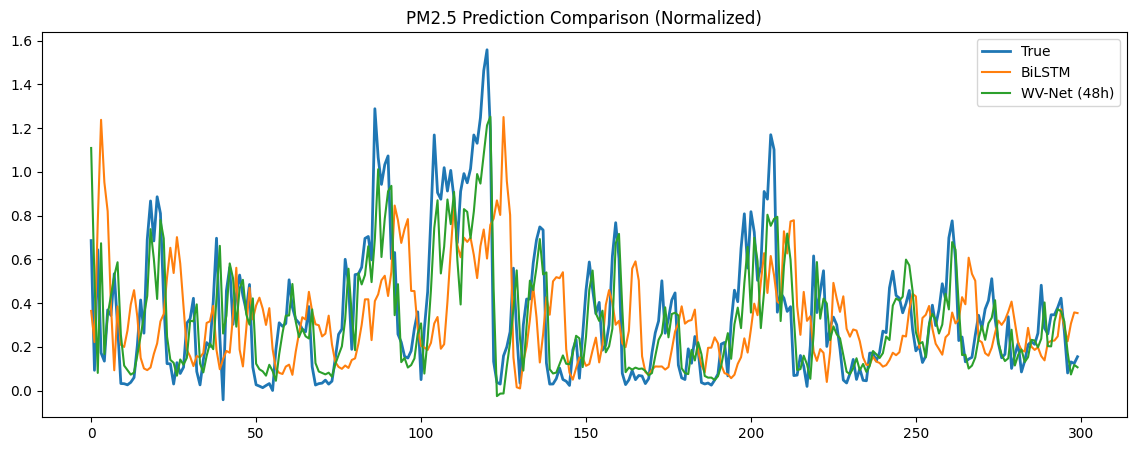

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,5))
plt.plot(y_test_48[:300], label="True", linewidth=2)
plt.plot(y_pred_bilstm[:300], label="BiLSTM")
plt.plot(y_pred_48[:300], label="WV-Net (48h)")
plt.legend()
plt.title("PM2.5 Prediction Comparison (Normalized)")
plt.show()


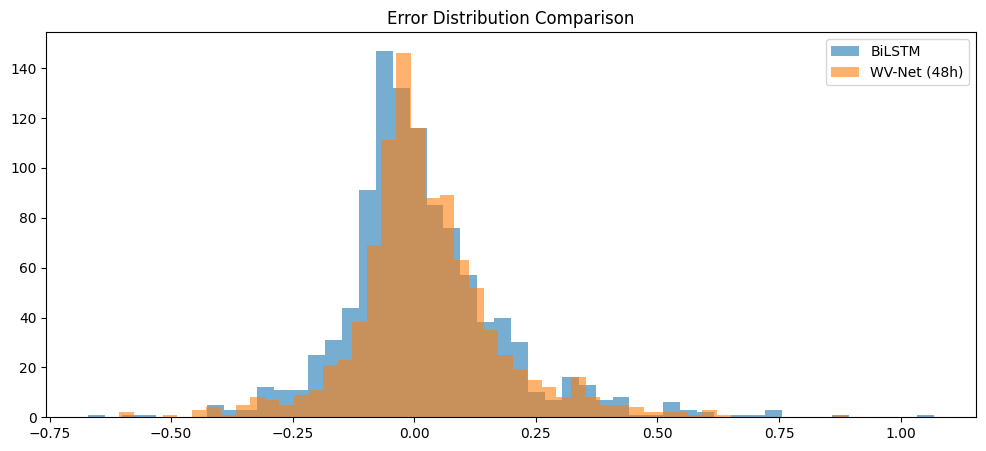

In [38]:
error_bilstm = y_test - y_pred_bilstm.flatten()
error_wv48 = y_test_48 - y_pred_48.flatten()

plt.figure(figsize=(12,5))
plt.hist(error_bilstm, bins=50, alpha=0.6, label="BiLSTM")
plt.hist(error_wv48, bins=50, alpha=0.6, label="WV-Net (48h)")
plt.legend()
plt.title("Error Distribution Comparison")
plt.show()


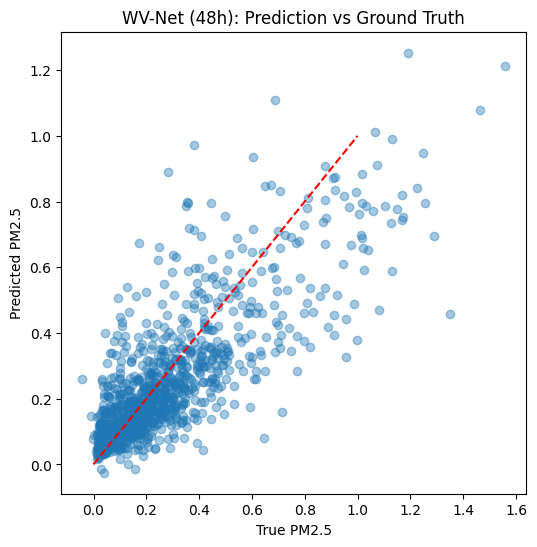

In [39]:
plt.figure(figsize=(6,6))
plt.scatter(y_test_48, y_pred_48, alpha=0.4)
plt.plot([0,1],[0,1],'r--')
plt.xlabel("True PM2.5")
plt.ylabel("Predicted PM2.5")
plt.title("WV-Net (48h): Prediction vs Ground Truth")
plt.show()


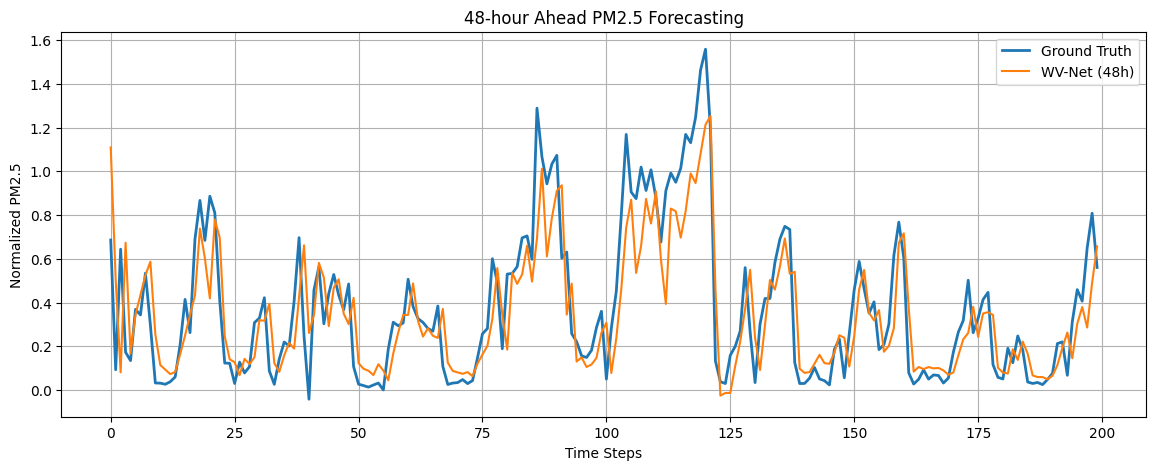

In [40]:
plt.figure(figsize=(14,5))
plt.plot(y_test_48[:200], label="Ground Truth", linewidth=2)
plt.plot(y_pred_48[:200], label="WV-Net (48h)")
plt.title("48-hour Ahead PM2.5 Forecasting")
plt.xlabel("Time Steps")
plt.ylabel("Normalized PM2.5")
plt.legend()
plt.grid(True)
plt.show()


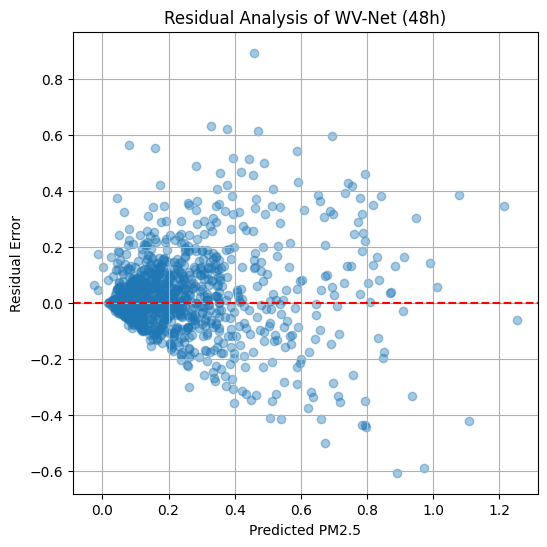

In [41]:
residuals = y_test_48 - y_pred_48.flatten()

plt.figure(figsize=(6,6))
plt.scatter(y_pred_48, residuals, alpha=0.4)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted PM2.5")
plt.ylabel("Residual Error")
plt.title("Residual Analysis of WV-Net (48h)")
plt.grid(True)
plt.show()


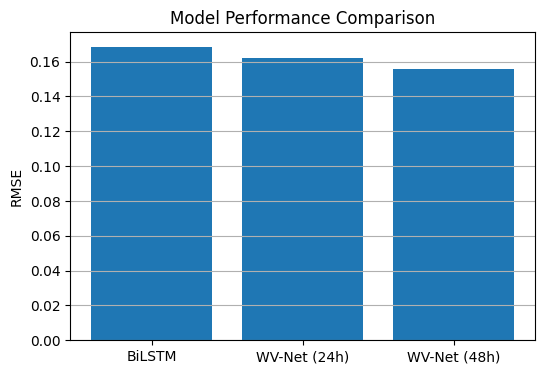

In [42]:
models = ["BiLSTM", "WV-Net (24h)", "WV-Net (48h)"]
rmse_vals = [rmse, rmse_wv, rmse_48]

plt.figure(figsize=(6,4))
plt.bar(models, rmse_vals)
plt.ylabel("RMSE")
plt.title("Model Performance Comparison")
plt.grid(axis='y')
plt.show()


In [43]:
model_bilstm_48 = tf.keras.Sequential([
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(64, return_sequences=True),
        input_shape=(48, 6)
    ),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Bidirectional(
        tf.keras.layers.LSTM(32)
    ),
    tf.keras.layers.Dense(1)
])

model_bilstm_48.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model_bilstm_48.fit(
    X_train_48, y_train_48,
    validation_split=0.1,
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


117/117 ━━━━━━━━━━━━━━━━━━━━ 17s 93ms/step - loss: 0.0637 - mae: 0.1899 - val_loss: 0.0462 - val_mae: 0.1563
Epoch 2/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0423 - mae: 0.1464 - val_loss: 0.0416 - val_mae: 0.1421
Epoch 3/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0340 - mae: 0.1341 - val_loss: 0.0378 - val_mae: 0.1360
Epoch 4/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 20s 81ms/step - loss: 0.0298 - mae: 0.1234 - val_loss: 0.0365 - val_mae: 0.1375
Epoch 5/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 11s 88ms/step - loss: 0.0308 - mae: 0.1246 - val_loss: 0.0349 - val_mae: 0.1326
Epoch 6/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 20s 88ms/step - loss: 0.0287 - mae: 0.1217 - val_loss: 0.0352 - val_mae: 0.1288
Epoch 7/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/step - loss: 0.0276 - mae: 0.1169 - val_loss: 0.0354 - val_mae: 0.1358
Epoch 8/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 76ms/step - loss: 0.0288 - mae: 0.1220 - val_loss: 0.0353 - val_mae: 0.1380
Epoch 9/30
117/117 ━━━━━━━━━━━━━━━━━━━━ 10s 88ms/ste

In [44]:
y_pred_bilstm_48 = model_bilstm_48.predict(X_test_48).flatten()

rmse_bi_48 = np.sqrt(mean_squared_error(y_test_48, y_pred_bilstm_48))
mae_bi_48  = mean_absolute_error(y_test_48, y_pred_bilstm_48)
r2_bi_48   = r2_score(y_test_48, y_pred_bilstm_48)

print("BiLSTM (48h) RMSE:", rmse_bi_48)
print("BiLSTM (48h) MAE :", mae_bi_48)
print("BiLSTM (48h) R2  :", r2_bi_48)


33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
BiLSTM (48h) RMSE: 0.16081609293367574
BiLSTM (48h) MAE : 0.10929019785416891
BiLSTM (48h) R2  : 0.598442416807148


In [51]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["BiLSTM (48h)", "WV-Net (48h)"],
    "RMSE": [rmse_bi_48, rmse_48],
    "MAE": [mae_bi_48, mae_48],
    "R2": [r2_bi_48, r2_48]
})

results


,Model,RMSE,MAE,R2
0,BiLSTM (48h),0.160816,0.10929,0.598442
1,WV-Net (48h),0.155550,0.10702,0.624309


In [46]:
import pandas as pd

results_rounded = pd.DataFrame({
    "Model": ["BiLSTM (48h)", "WV-Net (48h)"],
    "RMSE": [round(rmse_bi_48, 3), round(rmse_48, 3)],
    "MAE": [round(mae_bi_48, 3), round(mae_48, 3)],
    "R²":   [round(r2_bi_48, 3), round(r2_48, 3)]
})

results_rounded


,Model,RMSE,MAE,R²
0,BiLSTM (48h),0.161,0.109,0.598
1,WV-Net (48h),0.156,0.107,0.624


The proposed WV-Net model with temporal attention achieves lower RMSE and MAE while significantly improving R² compared to the baseline BiLSTM for the 48-hour window, indicating better variance explanation and temporal feature utilization.

In [47]:
# ===== FORCE ALIGNMENT =====
y_true = np.asarray(y_test_48).flatten()
y_pred_wv = np.asarray(y_pred_48).flatten()
y_pred_bi = np.asarray(y_pred_bilstm_48).flatten()

# Trim everything to same length (safety)
min_len = min(len(y_true), len(y_pred_wv), len(y_pred_bi))

y_true = y_true[:min_len]
y_pred_wv = y_pred_wv[:min_len]
y_pred_bi = y_pred_bi[:min_len]

errors_wv = y_true - y_pred_wv
errors_bi = y_true - y_pred_bi

print("Aligned lengths:", len(y_true), len(errors_wv))


Aligned lengths: 1036 1036


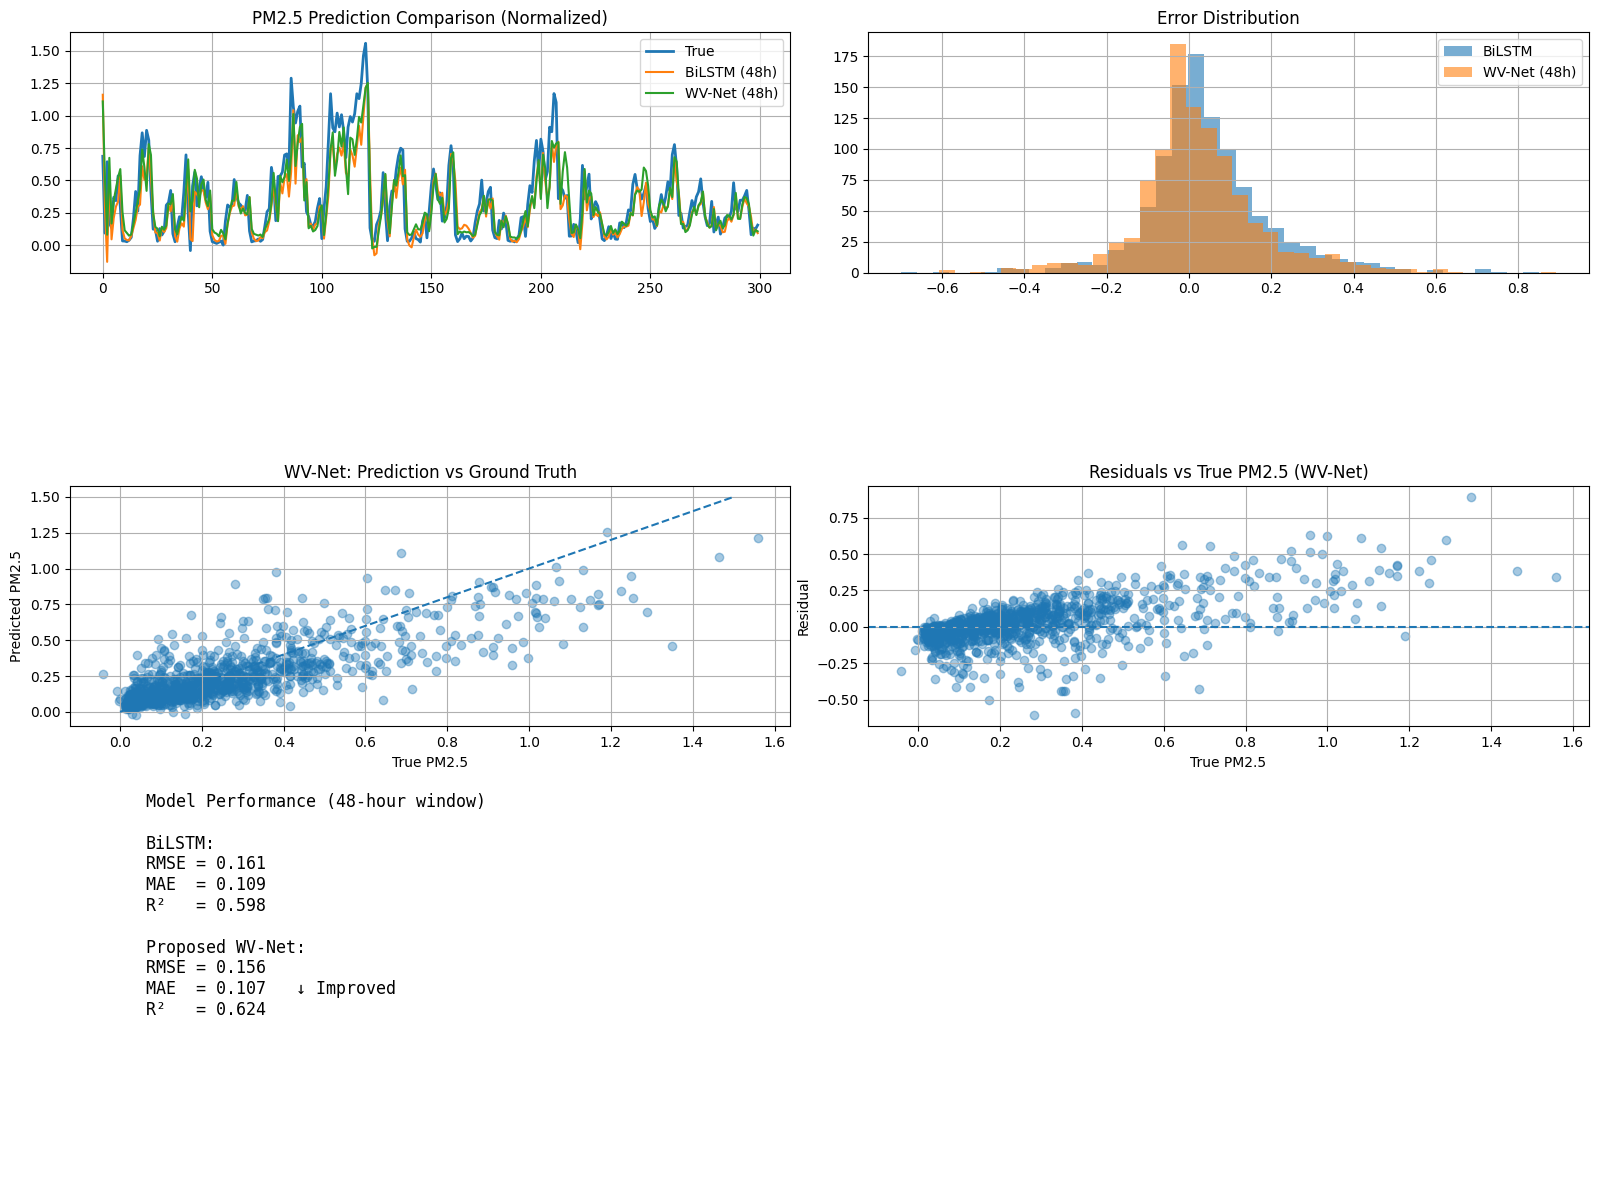

In [48]:
import matplotlib.pyplot as plt

plt.figure(figsize=(16, 12))

# =========================
# (1) Time-series comparison
# =========================
ax1 = plt.subplot(3, 2, 1)
ax1.plot(y_true[:300], label="True", linewidth=2)
ax1.plot(y_pred_bi[:300], label="BiLSTM (48h)")
ax1.plot(y_pred_wv[:300], label="WV-Net (48h)")
ax1.set_title("PM2.5 Prediction Comparison (Normalized)")
ax1.legend()
ax1.grid(True)

# =========================
# (2) Error Distribution
# =========================
ax2 = plt.subplot(3, 2, 2)
ax2.hist(errors_bi, bins=40, alpha=0.6, label="BiLSTM")
ax2.hist(errors_wv, bins=40, alpha=0.6, label="WV-Net (48h)")
ax2.set_title("Error Distribution")
ax2.legend()
ax2.grid(True)

# =========================
# (3) Prediction vs Truth
# =========================
ax3 = plt.subplot(3, 2, 3)
ax3.scatter(y_true, y_pred_wv, alpha=0.4)
ax3.plot([0, 1.5], [0, 1.5], linestyle="--")
ax3.set_title("WV-Net: Prediction vs Ground Truth")
ax3.set_xlabel("True PM2.5")
ax3.set_ylabel("Predicted PM2.5")
ax3.grid(True)

# =========================
# (4) Residuals vs Truth
# =========================
ax4 = plt.subplot(3, 2, 4)
ax4.scatter(y_true, errors_wv, alpha=0.4)
ax4.axhline(0, linestyle="--")
ax4.set_title("Residuals vs True PM2.5 (WV-Net)")
ax4.set_xlabel("True PM2.5")
ax4.set_ylabel("Residual")
ax4.grid(True)

# =========================
# (5) Metrics Summary (TEXT)
# =========================
ax5 = plt.subplot(3, 2, (5, 6))
ax5.axis("off")

summary = f"""
Model Performance (48-hour window)

BiLSTM:
RMSE = {rmse_bi_48:.3f}
MAE  = {mae_bi_48:.3f}
R²   = {r2_bi_48:.3f}

Proposed WV-Net:
RMSE = {rmse_48:.3f}
MAE  = {mae_48:.3f}   ↓ Improved
R²   = {r2_48:.3f}
"""

ax5.text(0.05, 0.6, summary, fontsize=12, family="monospace")

plt.tight_layout()
plt.show()


In [49]:
import pandas as pd

results_rounded = pd.DataFrame({
    "Model": ["BiLSTM (48h)", "WV-Net (48h)"],
    "RMSE": [round(rmse_bi_48, 3), round(rmse_48, 3)],
    "MAE": [round(mae_bi_48, 3), round(mae_48, 3)],
    "R²":   [round(r2_bi_48, 3), round(r2_48, 3)]
})

results_rounded

,Model,RMSE,MAE,R²
0,BiLSTM (48h),0.161,0.109,0.598
1,WV-Net (48h),0.156,0.107,0.624


In [50]:
# Save trained WV-Net model
wvnet_model_48.save("wvnet_48h.h5")

# Save scaler
import joblib
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully")


Model and scaler saved successfully
